In [2]:
import numpy as np
import pandas as pd
# read csv file

data = pd.read_csv('/home/Shared/datasets/POI_data/Safegraph/safegraph_pois_LA_County.csv')

In [3]:
data.shape

(50216, 30)

In [3]:
data.head()

,placekey,safegraph_place_id,parent_placekey,parent_safegraph_place_id,safegraph_brand_ids,location_name,brands,top_category,sub_category,naics_code,...,tracking_opened_since,tracking_closed_since,polygon_wkt,polygon_class,building_height,enclosed,phone_number,is_synthetic,includes_parking_lot,iso_country_code
0,22d-226@5z5-3r8-wkz,sg:038ef9a91adc47028e22996dcef58ba5,NaN,NaN,NaN,Legacy Tours,NaN,Travel Arrangement and Reservation Services,Travel Agencies,561510.0,...,NaN,2019-07,POLYGON ((-118.33077120505618 34.1013164999999...,SHARED_POLYGON,7.96,False,1.323301e+10,False,False,US
1,zzy-22c@5pw-624-hkf,sg:0741af758a484346ae1cf66f6e0a1333,NaN,NaN,NaN,Chicago Food Trucks,NaN,Grocery Stores,Supermarkets and Other Grocery (except Conveni...,445110.0,...,NaN,2019-07,"POLYGON ((-87.625169 41.900682, -87.624482 41....",SHARED_POLYGON,NaN,False,NaN,False,False,US
2,zzw-222@5pw-6rd-ndv,sg:074fe0fa448543c498965e9e36f3f81b,NaN,NaN,NaN,Universal Cuts,NaN,NaN,NaN,NaN,...,NaN,2019-07,POLYGON ((-87.75518953800201 41.96127518560561...,OWNED_POLYGON,NaN,False,1.773482e+10,False,NaN,US
3,zzy-222@5pw-6c7-6zf,sg:09038a5a904c4458bb545dedcb8ed935,NaN,NaN,NaN,Mckinley Trumbull Park Day Care,NaN,Child Day Care Services,Child Day Care Services,624410.0,...,NaN,2019-07,"POLYGON ((-87.56575591985906 41.703945, -87.56...",OWNED_POLYGON,NaN,False,1.773979e+10,True,NaN,US
4,zzy-222@627-wc7-z4v,sg:0bb9f91e6071444cb3c3673f6c162775,NaN,NaN,NaN,Special Special,NaN,Shoe Stores,Shoe Stores,448210.0,...,NaN,2019-07,"POLYGON ((-73.98971 40.724067, -73.989788 40.7...",OWNED_POLYGON,16.67,False,NaN,False,False,US


In [9]:
nan_category_rows = data[data['open_hours'].isna()]

In [11]:
len(nan_category_rows)

169801

In [18]:
data['venueCategory'].unique()

array(['Arts & Crafts Store', 'Bridge', 'Home (private)',
       'Medical Center', 'Food Truck', 'Food & Drink Shop', 'Coffee Shop',
       'Bus Station', 'Bank', 'Gastropub', 'Electronics Store',
       'Mobile Phone Shop', 'Café', 'Automotive Shop', 'Restaurant',
       'American Restaurant', 'Government Building', 'Airport', 'Ferry',
       'Office', 'Other Great Outdoors', 'Building', 'Mexican Restaurant',
       'Music Venue', 'Subway', 'Student Center', 'Park', 'Road',
       'Burger Joint', 'Sporting Goods Shop', 'Pizza Place',
       'Jewelry Store', 'Sandwich Place', 'Clothing Store',
       'Neighborhood', 'Ice Cream Shop', 'Soup Place',
       'College Academic Building', 'Department Store', 'Playground',
       'Tattoo Parlor', 'Mall', 'Deli / Bodega', 'University', 'Diner',
       'Music Store', 'Light Rail', 'Salon / Barbershop',
       'General College & University', 'Animal Shelter',
       'Laundry Service', 'Residential Building (Apartment / Condo)',
       'Drugstore

In [19]:
# drop the rows of that have category == 'Home (private)'

data_updated = data[data['venueCategory'] != 'Home (private)']

data_updated.shape

(212046, 10)

In [21]:
data_updated['userId'].unique().shape

(1083,)

In [25]:
visits_per_user = data_updated['userId'].value_counts()

# Compute stats
min_visits = visits_per_user.min()
max_visits = visits_per_user.max()
avg_visits = visits_per_user.mean()

print(f"Min visits per user: {min_visits}")
print(f"Max visits per user: {max_visits}")
print(f"Avg visits per user: {avg_visits:.2f}")

Min visits per user: 40
Max visits per user: 2328
Avg visits per user: 195.80


In [26]:
# find all the POIs that the 'distance' attribute is > 0.1

matched_pois = data_updated[data_updated['distance'] <= 0.1]

print(matched_pois.shape)

(127504, 10)


In [28]:
matched_pois['venueId'].unique().shape

(20761,)

In [29]:
# create a histogram of unmatched POIs per venueCategory

matched_pois['venueCategory'].value_counts()

venueCategory
Bar                         11761
Office                      10499
Gym / Fitness Center         6513
Subway                       6043
Coffee Shop                  5586
                            ...  
Castle                          2
Racetrack                       1
Bike Rental / Bike Share        1
Gluten-free Restaurant          1
Photography Lab                 1
Name: count, Length: 247, dtype: int64

In [31]:
import numpy as np
import pandas as pd
# read csv file

safegraph_pois = pd.read_csv('/home/Shared/core_poi-geometry.csv')

In [32]:
safegraph_pois.columns

Index(['placekey', 'safegraph_place_id', 'parent_placekey',
       'parent_safegraph_place_id', 'safegraph_brand_ids', 'location_name',
       'brands', 'top_category', 'sub_category', 'naics_code', 'latitude',
       'longitude', 'street_address', 'city', 'region', 'postal_code',
       'open_hours', 'category_tags', 'opened_on', 'closed_on',
       'tracking_opened_since', 'tracking_closed_since', 'polygon_wkt',
       'polygon_class', 'building_height', 'enclosed', 'phone_number',
       'is_synthetic', 'includes_parking_lot', 'iso_country_code'],
      dtype='object')

In [33]:
safegraph_pois.head()

,placekey,safegraph_place_id,parent_placekey,parent_safegraph_place_id,safegraph_brand_ids,location_name,brands,top_category,sub_category,naics_code,...,tracking_opened_since,tracking_closed_since,polygon_wkt,polygon_class,building_height,enclosed,phone_number,is_synthetic,includes_parking_lot,iso_country_code
0,22d-226@5z5-3r8-wkz,sg:038ef9a91adc47028e22996dcef58ba5,NaN,NaN,NaN,Legacy Tours,NaN,Travel Arrangement and Reservation Services,Travel Agencies,561510.0,...,NaN,2019-07,POLYGON ((-118.33077120505618 34.1013164999999...,SHARED_POLYGON,7.96,False,1.323301e+10,False,False,US
1,zzy-22c@5pw-624-hkf,sg:0741af758a484346ae1cf66f6e0a1333,NaN,NaN,NaN,Chicago Food Trucks,NaN,Grocery Stores,Supermarkets and Other Grocery (except Conveni...,445110.0,...,NaN,2019-07,"POLYGON ((-87.625169 41.900682, -87.624482 41....",SHARED_POLYGON,NaN,False,NaN,False,False,US
2,zzw-222@5pw-6rd-ndv,sg:074fe0fa448543c498965e9e36f3f81b,NaN,NaN,NaN,Universal Cuts,NaN,NaN,NaN,NaN,...,NaN,2019-07,POLYGON ((-87.75518953800201 41.96127518560561...,OWNED_POLYGON,NaN,False,1.773482e+10,False,NaN,US
3,zzy-222@5pw-6c7-6zf,sg:09038a5a904c4458bb545dedcb8ed935,NaN,NaN,NaN,Mckinley Trumbull Park Day Care,NaN,Child Day Care Services,Child Day Care Services,624410.0,...,NaN,2019-07,"POLYGON ((-87.56575591985906 41.703945, -87.56...",OWNED_POLYGON,NaN,False,1.773979e+10,True,NaN,US
4,zzy-222@627-wc7-z4v,sg:0bb9f91e6071444cb3c3673f6c162775,NaN,NaN,NaN,Special Special,NaN,Shoe Stores,Shoe Stores,448210.0,...,NaN,2019-07,"POLYGON ((-73.98971 40.724067, -73.989788 40.7...",OWNED_POLYGON,16.67,False,NaN,False,False,US


In [34]:
safegraph_pois['includes_parking_lot'].value_counts()

includes_parking_lot
False    232531
True       4910
Name: count, dtype: int64

In [40]:
matched_pois.shape

(127504, 10)

In [44]:
matched_pois.head(3)

,userId,venueId,venueCategoryId,venueCategory,latitude,longitude,timezoneOffset,utcTimestamp,nearest_poi,distance
0,470,49bbd6c0f964a520f4531fe3,4bf58dd8d48988d127951735,Arts & Crafts Store,40.719810,-74.002581,-240,Tue Apr 03 18:00:09 +0000 2012,sg:248cdb9b7e024d2ba134caf103092649,0.012531
3,395,4bc7086715a7ef3bef9878da,4bf58dd8d48988d104941735,Medical Center,40.745164,-73.982519,-240,Tue Apr 03 18:02:41 +0000 2012,sg:1333ec159a9e4e2ba5227cb5c6f4a11c,0.006629
4,87,4cf2c5321d18a143951b5cec,4bf58dd8d48988d1cb941735,Food Truck,40.740104,-73.989658,-240,Tue Apr 03 18:03:00 +0000 2012,sg:18edc989cb7c48e1b84f97a08b370e1f,0.005368


In [46]:
# add attributes of places dataset to tsmc_data by matching Venue ID

merged = matched_pois.merge(
    safegraph_pois,
    how='left',
    left_on='nearest_poi',
    right_on='safegraph_place_id',
    suffixes=('_fsq', '_sg')
)


In [47]:
merged.shape

(127504, 40)

In [53]:
merged.columns

Index(['userId', 'venueId', 'venueCategoryId', 'venueCategory', 'latitude_fsq',
       'longitude_fsq', 'timezoneOffset', 'utcTimestamp', 'nearest_poi',
       'distance', 'placekey', 'safegraph_place_id', 'parent_placekey',
       'parent_safegraph_place_id', 'safegraph_brand_ids', 'location_name',
       'brands', 'top_category', 'sub_category', 'naics_code', 'latitude_sg',
       'longitude_sg', 'street_address', 'city', 'region', 'postal_code',
       'open_hours', 'category_tags', 'opened_on', 'closed_on',
       'tracking_opened_since', 'tracking_closed_since', 'polygon_wkt',
       'polygon_class', 'building_height', 'enclosed', 'phone_number',
       'is_synthetic', 'includes_parking_lot', 'iso_country_code'],
      dtype='object')

In [56]:
merged['opened_on'].value_counts()

opened_on
2020-10    536
2020-11    224
2020-03    201
2020-08     31
2021-01     30
2020-04     29
2020-09     25
2019-10     15
2020-02     11
2019-08     10
2019-12      2
2020-05      2
2020-07      1
Name: count, dtype: int64

In [50]:
merged['latitude_sg'].head(3)

0    40.719738
1    40.745218
2    40.740135
Name: latitude_sg, dtype: float64

<Axes: ylabel='sub_category'>

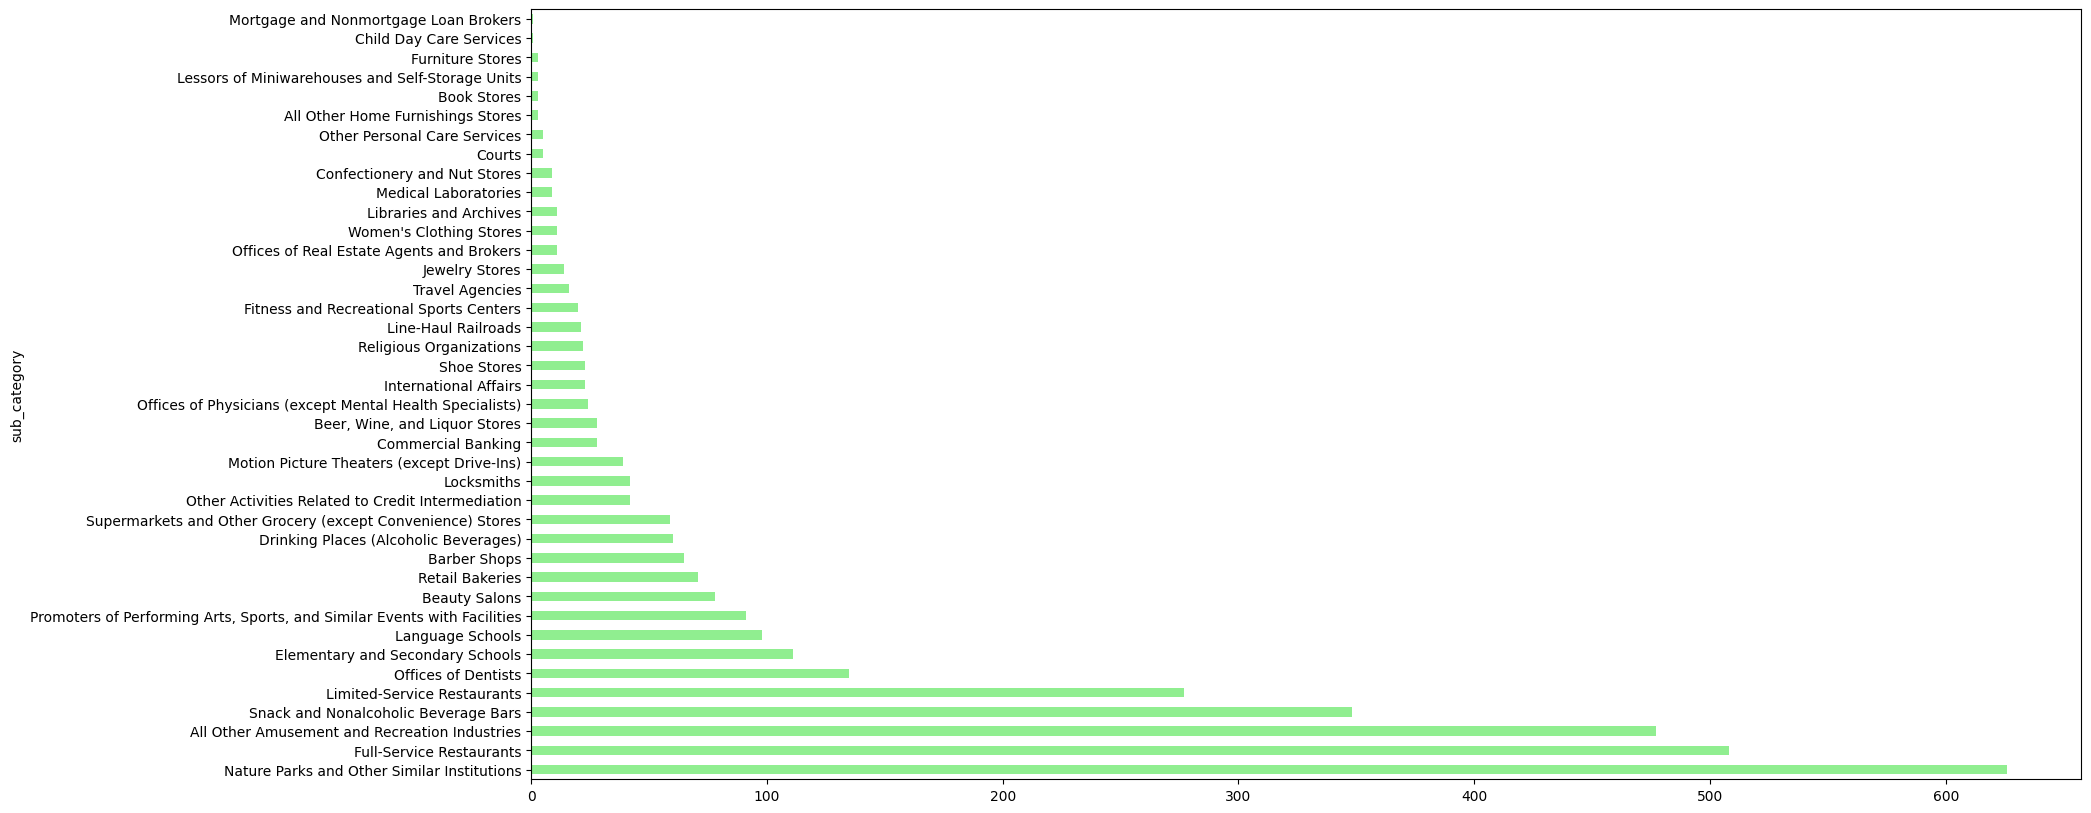

In [48]:
# keep the items with venue name category 'Home (private)' and plit their safegraph category

home_private = merged[merged['venueCategory'] == 'Home (private)']
home_private['sub_category'].value_counts().plot(kind='barh', figsize=(20, 10), color='lightgreen')

### Matching with Foursquare metadata

In [7]:
from datasets import load_dataset

# Load the 'places' subset
places_dataset = load_dataset("foursquare/fsq-os-places", data_files="release/dt=2025-01-10/places/parquet/*.parquet")

/home/maria/miniconda3/envs/googlefm/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Generating train split: 104588312 examples [06:30, 267665.74 examples/s]


In [8]:
places_dataset.shape

{'train': (104588312, 26)}

In [9]:
places_dataset.column_names

{'train': ['fsq_place_id',
  'name',
  'latitude',
  'longitude',
  'address',
  'locality',
  'region',
  'postcode',
  'admin_region',
  'post_town',
  'po_box',
  'country',
  'date_created',
  'date_refreshed',
  'date_closed',
  'tel',
  'website',
  'email',
  'facebook_id',
  'instagram',
  'twitter',
  'fsq_category_ids',
  'fsq_category_labels',
  'placemaker_url',
  'geom',
  'bbox']}

In [10]:
import pandas as pd
# load dataset_TSMC2014_NYC.txt dataset
columns = [
            "User ID", "Venue ID", "Venue Category ID", "Venue Category Name",
            "Latitude", "Longitude", "Timezone Offset", "UTC Time"
        ]

tsmc_data = pd.read_csv('/home/Shared/foursquare/dataset_TSMC2014_NYC.txt', encoding="ISO-8859-1", sep='\t', header=None, names=columns)

In [11]:
tsmc_data.head()

,User ID,Venue ID,Venue Category ID,Venue Category Name,Latitude,Longitude,Timezone Offset,UTC Time
0,470,49bbd6c0f964a520f4531fe3,4bf58dd8d48988d127951735,Arts & Crafts Store,40.719810,-74.002581,-240,Tue Apr 03 18:00:09 +0000 2012
1,979,4a43c0aef964a520c6a61fe3,4bf58dd8d48988d1df941735,Bridge,40.606800,-74.044170,-240,Tue Apr 03 18:00:25 +0000 2012
2,69,4c5cc7b485a1e21e00d35711,4bf58dd8d48988d103941735,Home (private),40.716162,-73.883070,-240,Tue Apr 03 18:02:24 +0000 2012
3,395,4bc7086715a7ef3bef9878da,4bf58dd8d48988d104941735,Medical Center,40.745164,-73.982519,-240,Tue Apr 03 18:02:41 +0000 2012
4,87,4cf2c5321d18a143951b5cec,4bf58dd8d48988d1cb941735,Food Truck,40.740104,-73.989658,-240,Tue Apr 03 18:03:00 +0000 2012


In [12]:
pois = places_dataset['train'].to_pandas()

In [13]:
# add attributes of places dataset to tsmc_data by matching Venue ID

merged = tsmc_data.merge(
    pois,
    how='left',
    left_on='nearest_poi',
    right_on='fsq_place_id',
    # suffixes=('_data', '_pois')
)


KeyError: 'nearest_poi'

In [18]:
merged.head()

,User ID,Venue ID,Venue Category ID,Venue Category Name,Latitude,Longitude,Timezone Offset,UTC Time,fsq_place_id,name,...,website,email,facebook_id,instagram,twitter,fsq_category_ids,fsq_category_labels,placemaker_url,geom,bbox
0,470,49bbd6c0f964a520f4531fe3,4bf58dd8d48988d127951735,Arts & Crafts Store,40.719810,-74.002581,-240,Tue Apr 03 18:00:09 +0000 2012,49bbd6c0f964a520f4531fe3,Pearl Art & Craft Supply,...,http://www.pearlpaint.com,None,NaN,None,PearlPaint,[4bf58dd8d48988d127951735],[Retail > Arts and Crafts Store],https://foursquare.com/placemakers/review-plac...,b'\x00\x00\x00\x00\x01\xc0R\x80(\x80Q7\x7f@D\\...,"{'xmin': -74.00247199946715, 'ymin': 40.719726..."
1,979,4a43c0aef964a520c6a61fe3,4bf58dd8d48988d1df941735,Bridge,40.606800,-74.044170,-240,Tue Apr 03 18:00:25 +0000 2012,4a43c0aef964a520c6a61fe3,Verrazano-Narrows Bridge,...,http://web.mta.info/bandt/html/veraz.html,None,NaN,None,None,[4bf58dd8d48988d1df941735],[Landmarks and Outdoors > Bridge],https://foursquare.com/placemakers/review-plac...,b'\x00\x00\x00\x00\x01\xc0R\x83\x1a\x11#=\xf3@...,"{'xmin': -74.048466, 'ymin': 40.605405, 'xmax'..."
2,69,4c5cc7b485a1e21e00d35711,4bf58dd8d48988d103941735,Home (private),40.716162,-73.883070,-240,Tue Apr 03 18:02:24 +0000 2012,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,395,4bc7086715a7ef3bef9878da,4bf58dd8d48988d104941735,Medical Center,40.745164,-73.982519,-240,Tue Apr 03 18:02:41 +0000 2012,4bc7086715a7ef3bef9878da,Premier Physical Therapy,...,https://www.professionalpt.com/office/murray-h...,reception1mh@premierptny.com,1.717472e+14,None,professionalpt_,[5744ccdfe4b0c0459246b4af],[Health and Medicine > Physical Therapy Clinic],https://foursquare.com/placemakers/review-plac...,"b""\x00\x00\x00\x00\x01\xc0R~\xde'\xdc\x89x@D_a...","{'xmin': -73.98230930840316, 'ymin': 40.745160..."
4,87,4cf2c5321d18a143951b5cec,4bf58dd8d48988d1cb941735,Food Truck,40.740104,-73.989658,-240,Tue Apr 03 18:03:00 +0000 2012,4cf2c5321d18a143951b5cec,Taïm Mobile Falafel & Smoothie Truck,...,http://www.taimmobile.com,None,1.163803e+14,None,taimmobile,"[4bf58dd8d48988d1cb941735, 4bf58dd8d48988d10b9...","[Dining and Drinking > Food Truck, Dining and ...",https://foursquare.com/placemakers/review-plac...,b'\x00\x00\x00\x00\x01\xc0R\x80[\x8d\xd4Z+@D]\...,"{'xmin': -74.00558801400682, 'ymin': 40.726855..."


In [20]:
merged.shape

(227428, 34)

In [23]:
tsmc_data.head(10)

,User ID,Venue ID,Venue Category ID,Venue Category Name,Latitude,Longitude,Timezone Offset,UTC Time
0,470,49bbd6c0f964a520f4531fe3,4bf58dd8d48988d127951735,Arts & Crafts Store,40.719810,-74.002581,-240,Tue Apr 03 18:00:09 +0000 2012
1,979,4a43c0aef964a520c6a61fe3,4bf58dd8d48988d1df941735,Bridge,40.606800,-74.044170,-240,Tue Apr 03 18:00:25 +0000 2012
2,69,4c5cc7b485a1e21e00d35711,4bf58dd8d48988d103941735,Home (private),40.716162,-73.883070,-240,Tue Apr 03 18:02:24 +0000 2012
3,395,4bc7086715a7ef3bef9878da,4bf58dd8d48988d104941735,Medical Center,40.745164,-73.982519,-240,Tue Apr 03 18:02:41 +0000 2012
4,87,4cf2c5321d18a143951b5cec,4bf58dd8d48988d1cb941735,Food Truck,40.740104,-73.989658,-240,Tue Apr 03 18:03:00 +0000 2012
5,484,4b5b981bf964a520900929e3,4bf58dd8d48988d118951735,Food & Drink Shop,40.690427,-73.954687,-240,Tue Apr 03 18:04:00 +0000 2012
6,642,4ab966c3f964a5203c7f20e3,4bf58dd8d48988d1e0931735,Coffee Shop,40.751591,-73.974121,-240,Tue Apr 03 18:04:38 +0000 2012
7,292,4d0cc47f903d37041864bf55,4bf58dd8d48988d12b951735,Bus Station,40.779422,-73.955341,-240,Tue Apr 03 18:04:42 +0000 2012
8,428,4ce1863bc4f6a35d8bd2db6c,4bf58dd8d48988d103941735,Home (private),40.619151,-74.035888,-240,Tue Apr 03 18:06:18 +0000 2012
9,877,4be319b321d5a59352311811,4bf58dd8d48988d10a951735,Bank,40.619006,-73.990375,-240,Tue Apr 03 18:06:19 +0000 2012


In [22]:
merged.head(10)

,User ID,Venue ID,Venue Category ID,Venue Category Name,Latitude,Longitude,Timezone Offset,UTC Time,fsq_place_id,name,...,website,email,facebook_id,instagram,twitter,fsq_category_ids,fsq_category_labels,placemaker_url,geom,bbox
0,470,49bbd6c0f964a520f4531fe3,4bf58dd8d48988d127951735,Arts & Crafts Store,40.719810,-74.002581,-240,Tue Apr 03 18:00:09 +0000 2012,49bbd6c0f964a520f4531fe3,Pearl Art & Craft Supply,...,http://www.pearlpaint.com,None,NaN,None,PearlPaint,[4bf58dd8d48988d127951735],[Retail > Arts and Crafts Store],https://foursquare.com/placemakers/review-plac...,b'\x00\x00\x00\x00\x01\xc0R\x80(\x80Q7\x7f@D\\...,"{'xmin': -74.00247199946715, 'ymin': 40.719726..."
1,979,4a43c0aef964a520c6a61fe3,4bf58dd8d48988d1df941735,Bridge,40.606800,-74.044170,-240,Tue Apr 03 18:00:25 +0000 2012,4a43c0aef964a520c6a61fe3,Verrazano-Narrows Bridge,...,http://web.mta.info/bandt/html/veraz.html,None,NaN,None,None,[4bf58dd8d48988d1df941735],[Landmarks and Outdoors > Bridge],https://foursquare.com/placemakers/review-plac...,b'\x00\x00\x00\x00\x01\xc0R\x83\x1a\x11#=\xf3@...,"{'xmin': -74.048466, 'ymin': 40.605405, 'xmax'..."
2,69,4c5cc7b485a1e21e00d35711,4bf58dd8d48988d103941735,Home (private),40.716162,-73.883070,-240,Tue Apr 03 18:02:24 +0000 2012,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,395,4bc7086715a7ef3bef9878da,4bf58dd8d48988d104941735,Medical Center,40.745164,-73.982519,-240,Tue Apr 03 18:02:41 +0000 2012,4bc7086715a7ef3bef9878da,Premier Physical Therapy,...,https://www.professionalpt.com/office/murray-h...,reception1mh@premierptny.com,1.717472e+14,None,professionalpt_,[5744ccdfe4b0c0459246b4af],[Health and Medicine > Physical Therapy Clinic],https://foursquare.com/placemakers/review-plac...,"b""\x00\x00\x00\x00\x01\xc0R~\xde'\xdc\x89x@D_a...","{'xmin': -73.98230930840316, 'ymin': 40.745160..."
4,87,4cf2c5321d18a143951b5cec,4bf58dd8d48988d1cb941735,Food Truck,40.740104,-73.989658,-240,Tue Apr 03 18:03:00 +0000 2012,4cf2c5321d18a143951b5cec,Taïm Mobile Falafel & Smoothie Truck,...,http://www.taimmobile.com,None,1.163803e+14,None,taimmobile,"[4bf58dd8d48988d1cb941735, 4bf58dd8d48988d10b9...","[Dining and Drinking > Food Truck, Dining and ...",https://foursquare.com/placemakers/review-plac...,b'\x00\x00\x00\x00\x01\xc0R\x80[\x8d\xd4Z+@D]\...,"{'xmin': -74.00558801400682, 'ymin': 40.726855..."
5,484,4b5b981bf964a520900929e3,4bf58dd8d48988d118951735,Food & Drink Shop,40.690427,-73.954687,-240,Tue Apr 03 18:04:00 +0000 2012,4b5b981bf964a520900929e3,Compare Foods Supermarket,...,http://comparesupermarkets.com,None,7.428691e+14,None,None,"[4bf58dd8d48988d118951735, 4bf58dd8d48988d1469...",[Retail > Food and Beverage Retail > Grocery S...,https://foursquare.com/placemakers/review-plac...,b'\x00\x00\x00\x00\x01\xc0R}\x1d\x12\xa8\x10\x...,"{'xmin': -73.95489946758926, 'ymin': 40.690077..."
6,642,4ab966c3f964a5203c7f20e3,4bf58dd8d48988d1e0931735,Coffee Shop,40.751591,-73.974121,-240,Tue Apr 03 18:04:38 +0000 2012,4ab966c3f964a5203c7f20e3,Starbucks,...,https://www.starbucks.com/store/12402/,info@starbucks.com,2.209244e+10,starbucks,starbucks,[4bf58dd8d48988d1e0931735],"[Dining and Drinking > Cafe, Coffee, and Tea H...",https://foursquare.com/placemakers/review-plac...,b'\x00\x00\x00\x00\x01\xc0R~O\xef\x8c?i@D`2h2\...,"{'xmin': -73.97362889, 'ymin': 40.7515383, 'xm..."
7,292,4d0cc47f903d37041864bf55,4bf58dd8d48988d12b951735,Bus Station,40.779422,-73.955341,-240,Tue Apr 03 18:04:42 +0000 2012,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,428,4ce1863bc4f6a35d8bd2db6c,4bf58dd8d48988d103941735,Home (private),40.619151,-74.035888,-240,Tue Apr 03 18:06:18 +0000 2012,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,877,4be319b321d5a59352311811,4bf58dd8d48988d10a951735,Bank,40.619006,-73.990375,-240,Tue Apr 03 18:06:19 +0000 2012,4be319b321d5a59352311811,Chase Bank,...,https://locator.chase.com/ny/brooklyn/6501-18t...,None,5.480186e+14,None,chasesupport,"[4bf58dd8d48988d10a951735, 52f2ab2ebcbc57f1066...",[Business and Professional 

In [24]:
# save the merged dataset to a new CSV file

merged.to_csv('/home/Shared/foursquare/dataset_TSMC2014_NYC_more_attributes.csv', index=False)

In [1]:
import pandas as pd

# load csv file
safegraph_pois = pd.read_csv('/home/Shared/core_poi-geometry.csv')

print(safegraph_pois.shape)

(283144, 30)


In [2]:
def filter_pois(bbox: dict, POIs: pd.DataFrame) -> pd.DataFrame:
    """Filter the DataFrame for points within the given bounding box."""
    if POIs.empty:
        print("DataFrame is empty. No filtering applied.")
        return POIs

    in_bbox = (
        (POIs['latitude'] >= bbox['min_lat']) &
        (POIs['latitude'] <= bbox['max_lat']) &
        (POIs['longitude'] >= bbox['min_lon']) &
        (POIs['longitude'] <= bbox['max_lon'])
    )
    
    filtered_df = POIs[in_bbox]
    return filtered_df

In [3]:
# Keep only POIs in los angeles
LA_bbox = {
        'min_lat': 32.75004,
        'max_lat': 34.823302,
        'min_lon': -118.951721,
        'max_lon': -117.646374
    }
LA_pois = filter_pois(LA_bbox, safegraph_pois)

In [5]:
LA_pois.shape

(50217, 30)

In [14]:
# plot bounding box on folium map

import folium
# Create a folium map centered around Los Angeles
map_la = folium.Map(location=[34.0522, -118.2437], zoom_start=10)
# Add bounding box rectangle
folium.Rectangle(
    bounds=[
        [LA_bbox['min_lat'], LA_bbox['min_lon']],
        [LA_bbox['max_lat'], LA_bbox['max_lon']]
    ],
    color='blue',
    fill=True,
    fill_opacity=0.1
).add_to(map_la)

map_la

In [16]:
import geopandas as gpd

counties = gpd.read_file("tl_2023_us_county.zip")

# Filter for Los Angeles County (FIPS: 06037)
la_county = counties[counties['GEOID'] == '06037']


In [17]:
la_county

,STATEFP,COUNTYFP,COUNTYNS,GEOID,GEOIDFQ,NAME,NAMELSAD,LSAD,CLASSFP,MTFCC,CSAFP,CBSAFP,METDIVFP,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
396,06,037,00277283,06037,0500000US06037,Los Angeles,Los Angeles County,06,H1,G4020,348,31080,31084,A,10515988121,1785003256,+34.1963983,-118.2618616,"MULTIPOLYGON (((-118.6782 33.03973, -118.6756 ..."


In [18]:
# Get center of the county for map initialization
centroid = la_county.geometry.centroid.iloc[0]
m = folium.Map(location=[centroid.y, centroid.x], zoom_start=9)

# Add boundary to the map
folium.GeoJson(la_county).add_to(m)

# Show map
m


/tmp/ipykernel_434017/438090023.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroid = la_county.geometry.centroid.iloc[0]


In [19]:
# save boundary as geojson file
la_county.to_file("/home/Shared/la_county_boundary.geojson", driver='GeoJSON')

/tmp/ipykernel_434017/2707040625.py:1: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  la_boundary_multi = la_county.geometry.unary_union


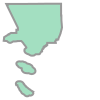

In [21]:
la_boundary_multi = la_county.geometry.unary_union

la_boundary_multi

In [26]:
# keep only the safegraph POIs that are within the LA county boundary

from shapely.geometry import Point

def filter_pois_by_boundary(boundary: gpd.GeoDataFrame, POIs: pd.DataFrame) -> pd.DataFrame:
    """Filter the DataFrame for points within the given boundary."""
    if POIs.empty or boundary.empty:
        print("DataFrame or boundary is empty. No filtering applied.")
        return POIs

    # Create a GeoDataFrame from the POIs
    gdf_pois = gpd.GeoDataFrame(
        POIs,
        geometry=gpd.points_from_xy(POIs['longitude'], POIs['latitude']),
        crs="EPSG:4326"  # WGS84
    )

    # Perform spatial join to filter POIs within the boundary
    gdf_pois_filtered = gdf_pois[gdf_pois.within(la_boundary_multi)]

    return gdf_pois_filtered

# Filter the LA POIs by the county boundary
LA_pois_filtered = filter_pois_by_boundary(la_county, safegraph_pois)
LA_pois_filtered.shape
# Save the filtered POIs to a new CSV file
# LA_pois_filtered.to_csv('/home/Shared/foursquare/safegraph_pois_LA_County.csv', index=False)

(50216, 31)

In [23]:
LA_pois.columns

Index(['placekey', 'safegraph_place_id', 'parent_placekey',
       'parent_safegraph_place_id', 'safegraph_brand_ids', 'location_name',
       'brands', 'top_category', 'sub_category', 'naics_code', 'latitude',
       'longitude', 'street_address', 'city', 'region', 'postal_code',
       'open_hours', 'category_tags', 'opened_on', 'closed_on',
       'tracking_opened_since', 'tracking_closed_since', 'polygon_wkt',
       'polygon_class', 'building_height', 'enclosed', 'phone_number',
       'is_synthetic', 'includes_parking_lot', 'iso_country_code'],
      dtype='object')

In [29]:
LA_pois_filtered.drop(columns=['geometry'], inplace=True)  # Drop the geometry column if it exists

In [30]:
# save the filtered POIs to a new CSV file
LA_pois_filtered.to_csv('/home/Shared/safegraph_pois_LA_County.csv', index=False)

In [25]:
safegraph_pois.shape

(283144, 30)